# WiDS Datathon 2025

The goal is to build a model to predict both an individual’s sex and their ADHD diagnosis using functional brain imaging data of children and adolescents and their socio-demographic, emotions, and parenting information. https://www.kaggle.com/competitions/widsdatathon2025/overview

**Dataset Folders**\
(1) the training folder train_new_tsv consists of three types of information about the 1,200+ subjects. They are:

a) the targets (ADHD diagnosis and sex)\
b) functional MRI connectome matrices\
c) socio-demographic information, e.g., subject’s “handedness” or “parent’s education level”, emotions (“Strength and Difficulties Questionnaire”), and parenting information (“Alabama Parenting Questionnaire”). These include both quantitative and categorical metadata.

**Friendly hint**: Participants will need to process the categorical data (perhaps create dummy variables) and then combine this processed dataset with the functional connectome dataset to create a final training dataset to use in their models.

(2) the test folder test_tsv consists of unseen data frames for 300+ subjects. These data frames are as follows:

a) functional MRI connectome matrices\
b) socio-demographic, emotions, and parenting information

**Target Variables**\
ADHD_Outcome: Type of Diagnosis (0=Other/None, 1=ADHD)\
Sex_F: Sex of participant (0=Male, 1=Female)

##### imports

In [5]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn.preprocessing as prep
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots 

import sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score

##### Helper Functions

In [7]:
def get_messing(df,drop=False):
    missing_data = pd.DataFrame({'Count': df.isnull().sum(),
                            '%':(df.isnull().sum()/df.shape[0]*100 ).round(2)
                            })
    if (missing_data[missing_data != 0].dropna().sum().sum() == 0) :
        print("No Messing Data")
    else : 
        if drop :
            return(missing_data[missing_data != 0].dropna())
        else: return(missing_data)

In [8]:
def handel_Outliers(df,Outlier_columns,handel = True):
    for col in Outlier_columns:
        print(col," : \n")
        # first get the IQR value then apply the rule
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        print(f"IQR = {IQR}")
        # Anything above the upper limit or lower than the lower limit is an outlier
        cut_off = IQR * 1.5
        lower = Q1 - cut_off
        upper =  Q3 + cut_off
        print(f"lower,upper bounds [{lower},{upper}]")
        
        u = df[df[col]> upper]
        l = df[df[col] < lower]
        print(F'Total number of outliers in {col} are {u.shape[0]+ l.shape[0]}')
        if handel:
            df.loc[df[col] < lower, col] = df[col].median()
            df.loc[df[col] > upper, col] = df[col].median()
        print("===========================================")   
    if handel:
        print("All ouliers Handeled successfully")

    return df

In [9]:
def multi_output_accuracy(y_true, y_pred):
    # Ensure y_true and y_pred are NumPy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Compute accuracy for each target variable and return the mean
    return np.mean([accuracy_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])])

# Create a scorer using scikit-learn's make_scorer
multi_output_scorer = make_scorer(multi_output_accuracy, greater_is_better=True)

# Load Data

In [11]:
# Train data
TRAIN_CATEGORICAL = pd.read_excel("TRAIN_NEW/TRAIN_CATEGORICAL_METADATA_new.xlsx")
TRAIN_FUNCTIONAL_CONNECTOME_MATRICES = pd.read_csv("TRAIN_NEW/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv")
TRAIN_QUANTITATIVE = pd.read_excel("TRAIN_NEW/TRAIN_QUANTITATIVE_METADATA_new.xlsx")
TRAINING_SOLUTIONS = pd.read_excel("TRAIN_NEW/TRAINING_SOLUTIONS.xlsx")

In [12]:
# Test data
TEST_CATEGORICAL = pd.read_excel("TEST/TEST_CATEGORICAL.xlsx")
TEST_FUNCTIONAL_CONNECTOME_MATRICES = pd.read_csv("TEST/TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv")
TEST_QUANTITATIVE_METADATA = pd.read_excel("TEST/TEST_QUANTITATIVE_METADATA.xlsx")

# EDA

In [14]:
id1 = TRAIN_CATEGORICAL.participant_id.sort_values().reset_index(drop=True)
id2 = TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.participant_id.sort_values().reset_index(drop=True)
id3 = TRAIN_QUANTITATIVE.participant_id.sort_values().reset_index(drop=True)

(id1.equals(id2)) and (id1.equals(id3))


True

All ids refer to the same persons

In [16]:
TRAIN_CATEGORICAL = TRAIN_CATEGORICAL.sort_values('participant_id').reset_index(drop=True)
TRAIN_FUNCTIONAL_CONNECTOME_MATRICES = TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.sort_values('participant_id').reset_index(drop=True)
TRAIN_QUANTITATIVE = TRAIN_QUANTITATIVE.sort_values('participant_id').reset_index(drop=True)
TRAINING_SOLUTIONS = TRAINING_SOLUTIONS.sort_values('participant_id').reset_index(drop=True)

## TRAINING_SOLUTIONS

In [18]:
TRAINING_SOLUTIONS.head()

,participant_id,ADHD_Outcome,Sex_F
0,00aIpNTbG5uh,1,0
1,00fV0OyyoLfw,1,0
2,04X1eiS79T4B,0,1
3,05ocQutkURd6,0,1
4,06YUNBA9ZRLq,1,0


In [19]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Create the subplot figure
fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.5, 0.5],
    specs=[[{"type": "domain"}, {"type": "domain"}]],
    subplot_titles=["Distribution of ADHD_Outcome", "Sex Distribution"]
)

df = TRAINING_SOLUTIONS.select_dtypes(include=['float64', 'int64'])

# Pie chart for ADHD_Outcome (1 = Has, 0 = No ADHD)
counts = df['ADHD_Outcome'].value_counts()
labels = ['Has ADHD' if val == 1 else 'No ADHD' for val in counts.index]
percentages = counts / counts.sum() * 100
label_with_pct = [f'{label} ({pct:.1f}%)' for label, pct in zip(labels, percentages)]

fig.add_trace(
    go.Pie(
        labels=label_with_pct,
        values=counts.values,
    ),
    row=1, col=1
)

# Pie chart for Sex_F (1 = Female, 0 = Male)
counts = df['Sex_F'].value_counts()
labels = ['Female' if val == 1 else 'Male' for val in counts.index]
percentages = counts / counts.sum() * 100
label_with_pct = [f'{label} ({pct:.1f}%)' for label, pct in zip(labels, percentages)]

fig.add_trace(
    go.Pie(
        labels=label_with_pct,
        values=counts.values,
    ),
    row=1, col=2
)

# Update layout
fig.update_layout(
    title_text="ADHD Outcome Distribution and Sex Breakdown",
    height=400
)

fig.show()

## TRAIN_CATEGORICAL

In [21]:
TRAIN_CATEGORICAL.head()

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
0,00aIpNTbG5uh,2019,4,1.0,0.0,3.0,21.0,45.0,NaN,NaN
1,00fV0OyyoLfw,2017,1,0.0,9.0,2.0,21.0,0.0,21.0,45.0
2,04X1eiS79T4B,2017,1,1.0,2.0,2.0,9.0,0.0,NaN,NaN
3,05ocQutkURd6,2018,1,3.0,8.0,2.0,18.0,10.0,18.0,0.0
4,06YUNBA9ZRLq,2018,1,0.0,1.0,2.0,12.0,0.0,NaN,NaN


In [22]:
TRAIN_CATEGORICAL.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   participant_id                    1213 non-null   object 
 1   Basic_Demos_Enroll_Year           1213 non-null   int64  
 2   Basic_Demos_Study_Site            1213 non-null   int64  
 3   PreInt_Demos_Fam_Child_Ethnicity  1170 non-null   float64
 4   PreInt_Demos_Fam_Child_Race       1159 non-null   float64
 5   MRI_Track_Scan_Location           1210 non-null   float64
 6   Barratt_Barratt_P1_Edu            1198 non-null   float64
 7   Barratt_Barratt_P1_Occ            1182 non-null   float64
 8   Barratt_Barratt_P2_Edu            1015 non-null   float64
 9   Barratt_Barratt_P2_Occ            991 non-null    float64
dtypes: float64(7), int64(2), object(1)
memory usage: 94.9+ KB


In [23]:
TRAIN_CATEGORICAL.describe()

,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
count,1213.000000,1213.000000,1170.000000,1159.000000,1210.000000,1198.000000,1182.000000,1015.000000,991.000000
mean,2017.652102,2.014839,0.435897,2.177739,2.294215,17.862270,25.545685,16.876847,30.257316
std,1.122522,1.135147,0.693174,3.204782,0.750660,3.505608,16.757043,3.929558,13.901144
min,2015.000000,1.000000,0.000000,0.000000,1.000000,3.000000,0.000000,3.000000,0.000000
25%,2017.000000,1.000000,0.000000,0.000000,2.000000,15.000000,5.000000,15.000000,20.000000
50%,2018.000000,1.000000,0.000000,1.000000,2.000000,18.000000,30.000000,18.000000,35.000000
75%,2019.000000,3.000000,1.000000,2.000000,3.000000,21.000000,40.000000,21.000000,40.000000
max,2020.000000,4.000000,3.000000,11.000000,4.000000,21.000000,45.000000,21.000000,45.000000


In [24]:
for col in TRAIN_CATEGORICAL.columns:
    print(f"{col}: {TRAIN_CATEGORICAL[col].unique()}")

participant_id: ['00aIpNTbG5uh' '00fV0OyyoLfw' '04X1eiS79T4B' ... 'zwBG0rZ05Mcb'
 'zwXD5v17Rx01' 'zwjJWCRzKhDz']
Basic_Demos_Enroll_Year: [2019 2017 2018 2016 2015 2020]
Basic_Demos_Study_Site: [4 1 2 3]
PreInt_Demos_Fam_Child_Ethnicity: [ 1.  0.  3.  2. nan]
PreInt_Demos_Fam_Child_Race: [ 0.  9.  2.  8.  1. 10.  4. nan  3. 11.  7.]
MRI_Track_Scan_Location: [ 3.  2.  1.  4. nan]
Barratt_Barratt_P1_Edu: [21.  9. 18. 12. 15.  3. nan  6.]
Barratt_Barratt_P1_Occ: [45.  0. 10. 35. 40. 25. nan 30. 15.  5. 20.]
Barratt_Barratt_P2_Edu: [nan 21. 18. 15. 12.  9.  6.  3.]
Barratt_Barratt_P2_Occ: [nan 45.  0. 30. 40. 15. 35.  5. 10. 20. 25.]


In [25]:
get_messing(TRAIN_CATEGORICAL)

,Count,%
participant_id,0,0.00
Basic_Demos_Enroll_Year,0,0.00
Basic_Demos_Study_Site,0,0.00
PreInt_Demos_Fam_Child_Ethnicity,43,3.54
PreInt_Demos_Fam_Child_Race,54,4.45
MRI_Track_Scan_Location,3,0.25
Barratt_Barratt_P1_Edu,15,1.24
Barratt_Barratt_P1_Occ,31,2.56
Barratt_Barratt_P2_Edu,198,16.32
Barratt_Barratt_P2_Occ,222,18.30


In [26]:
merged_df = pd.merge(TRAIN_CATEGORICAL, TRAINING_SOLUTIONS, on='participant_id', how='inner')
merged_df.head()

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ,ADHD_Outcome,Sex_F
0,00aIpNTbG5uh,2019,4,1.0,0.0,3.0,21.0,45.0,NaN,NaN,1,0
1,00fV0OyyoLfw,2017,1,0.0,9.0,2.0,21.0,0.0,21.0,45.0,1,0
2,04X1eiS79T4B,2017,1,1.0,2.0,2.0,9.0,0.0,NaN,NaN,0,1
3,05ocQutkURd6,2018,1,3.0,8.0,2.0,18.0,10.0,18.0,0.0,0,1
4,06YUNBA9ZRLq,2018,1,0.0,1.0,2.0,12.0,0.0,NaN,NaN,1,0


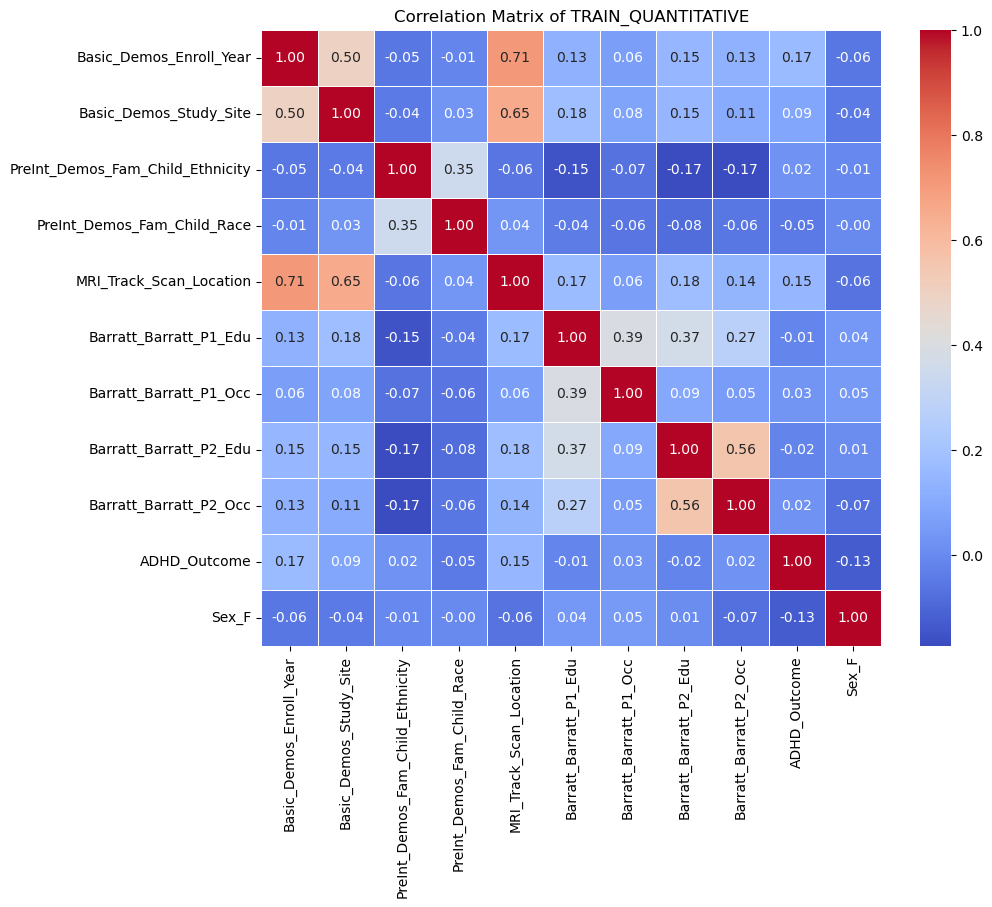

In [27]:
corr=merged_df.drop(['participant_id'],axis=1).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of TRAIN_QUANTITATIVE")
plt.show()

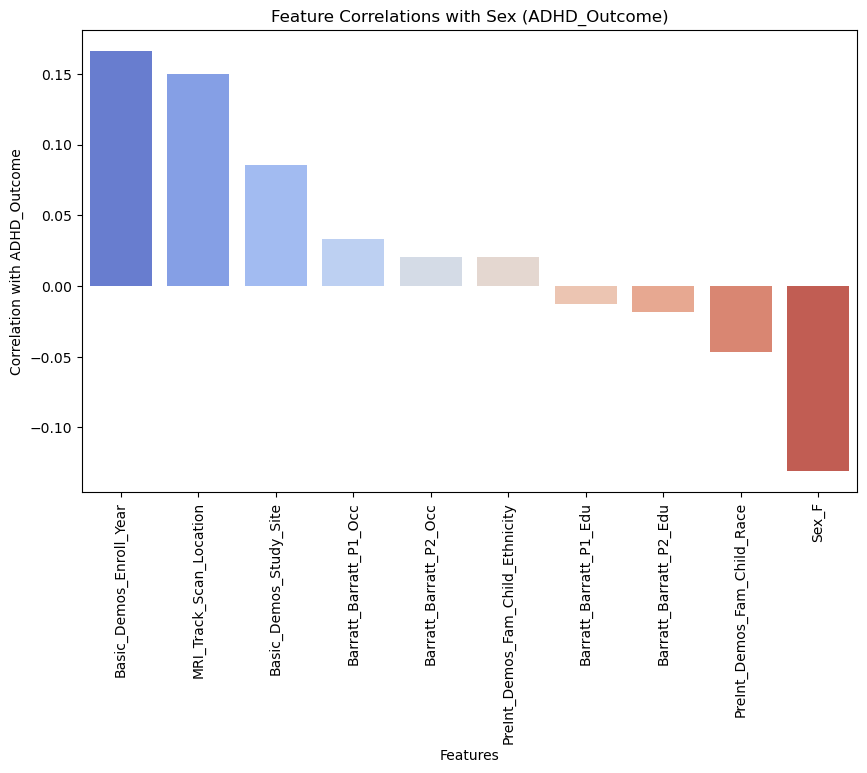

In [28]:
# Extract correlations of features with respect to 'ADHD_Outcome'
correlation_with_sex = corr['ADHD_Outcome'].drop('ADHD_Outcome').sort_values(ascending=False)

# Plot the correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_with_sex.index, y=correlation_with_sex.values, palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Correlation with ADHD_Outcome")
plt.title("Feature Correlations with Sex (ADHD_Outcome)")
plt.show()

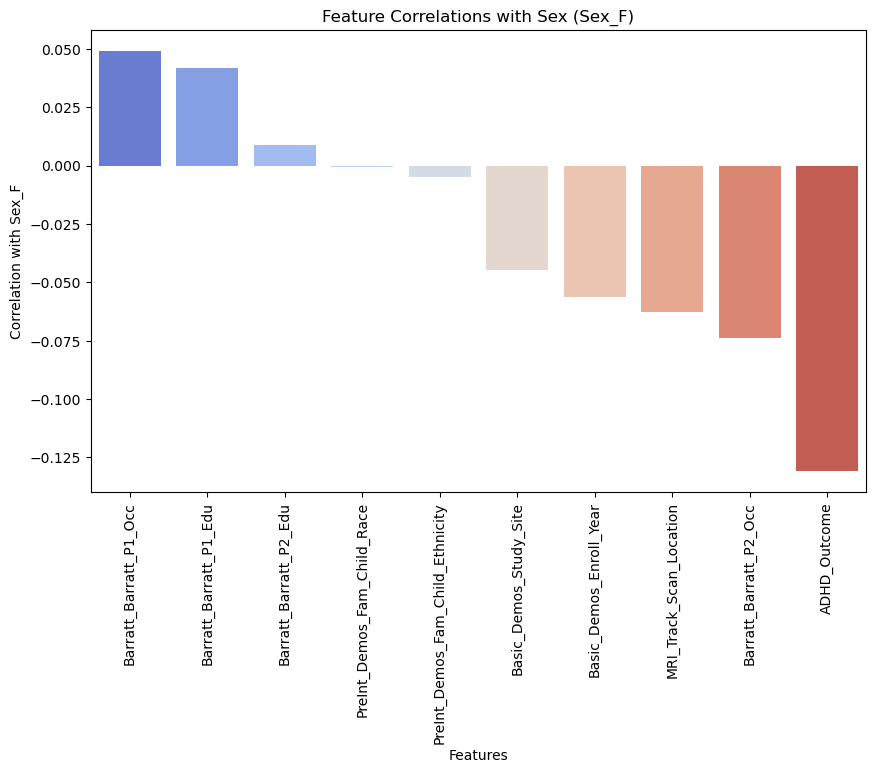

In [29]:
# Extract correlations of features with respect to 'Sex_F'
correlation_with_sex = corr['Sex_F'].drop('Sex_F').sort_values(ascending=False)

# Plot the correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_with_sex.index, y=correlation_with_sex.values, palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Correlation with Sex_F")
plt.title("Feature Correlations with Sex (Sex_F)")
plt.show()

### Distribution of columns

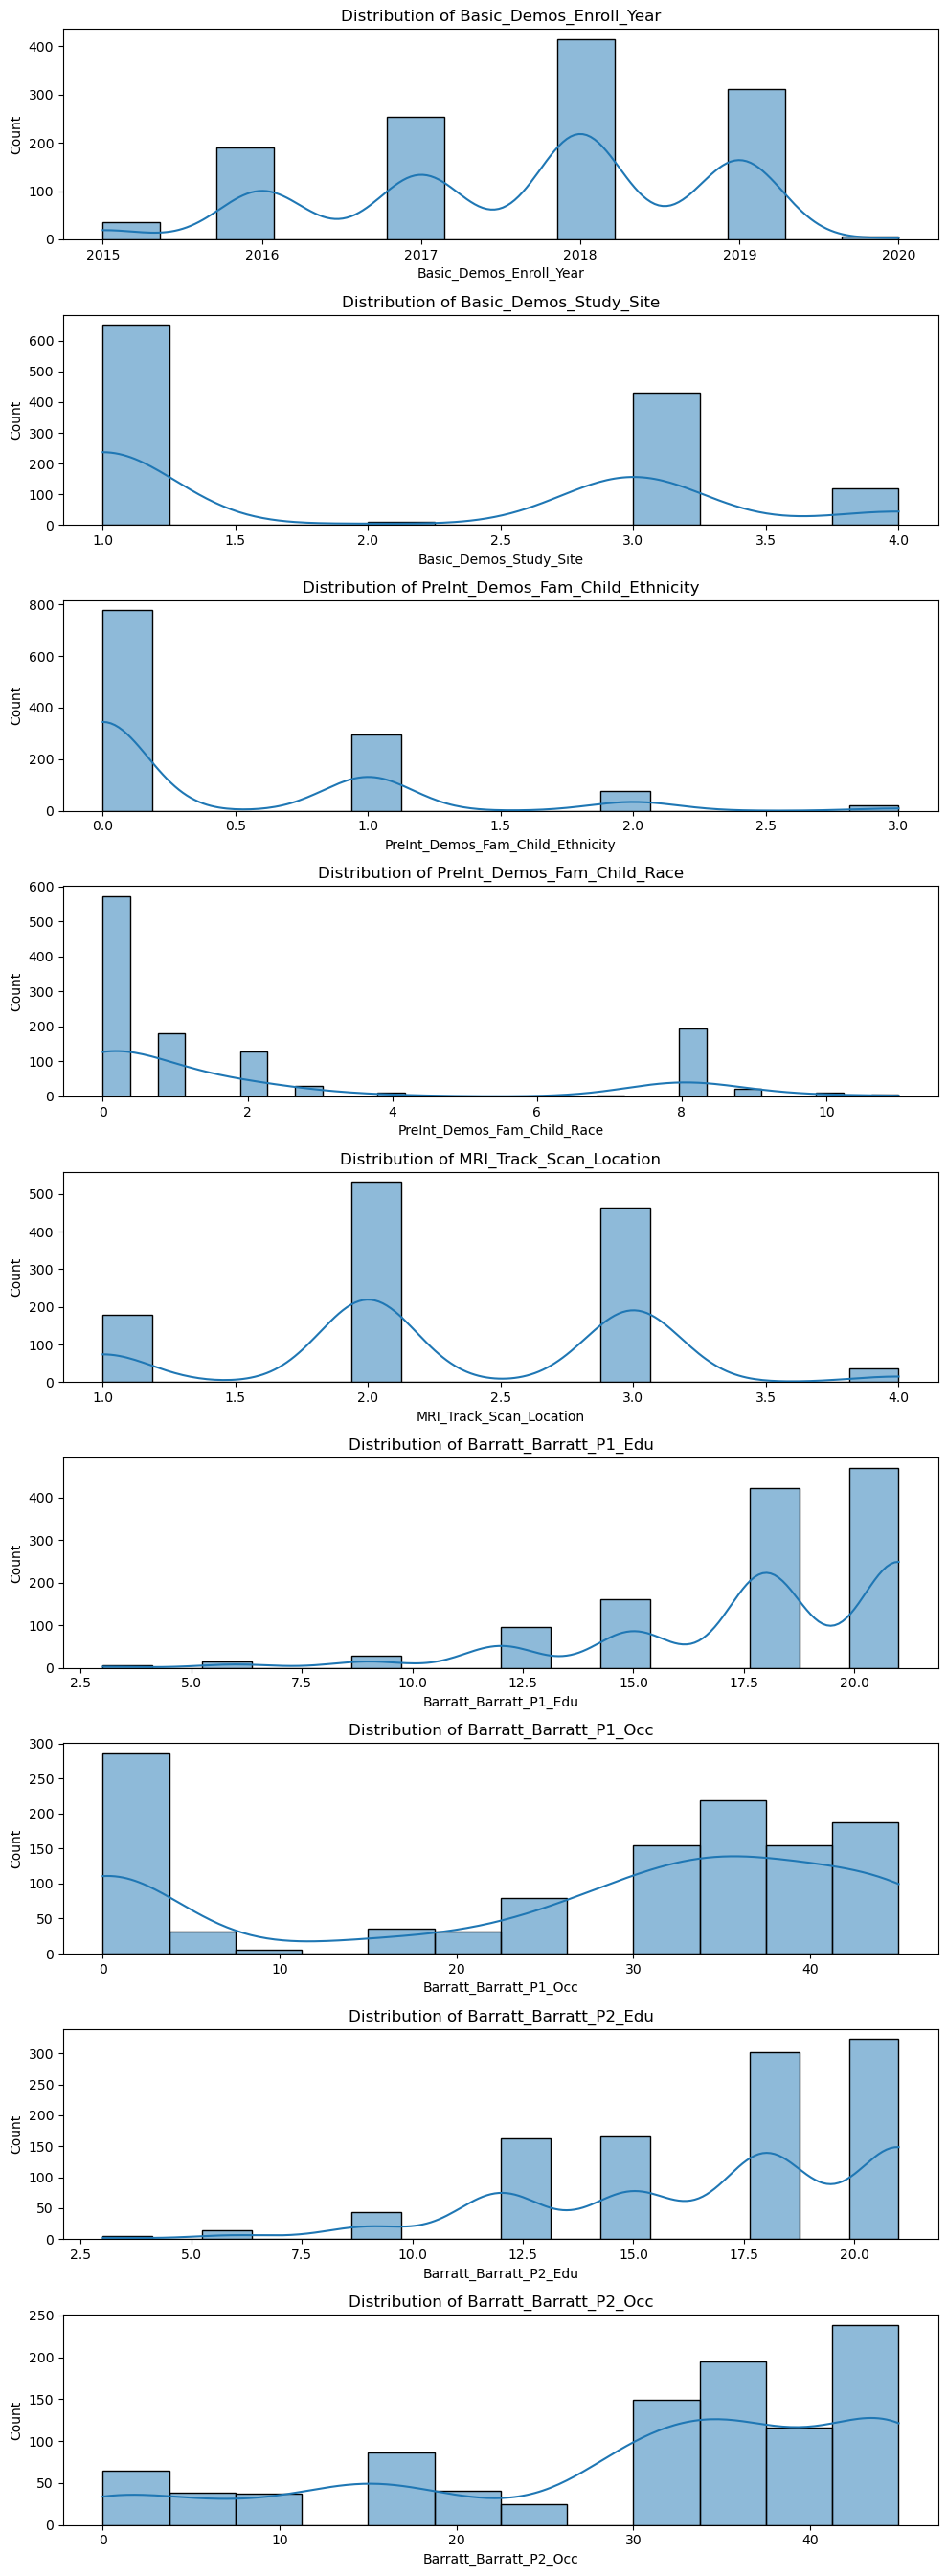

In [31]:
numeric_df = TRAIN_CATEGORICAL.select_dtypes(include=['float64', 'int64'])
num_columns = len(numeric_df.columns)

# Create one subplot per numeric column
fig, axes = plt.subplots(num_columns, 1, figsize=(10, num_columns * 3))

for i, column in enumerate(numeric_df.columns):
    sns.histplot(numeric_df[column], ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

## TRAIN_FUNCTIONAL_CONNECTOME_MATRICES

Functional connectivity matrices are always square and symmetric, corresponding to the
number of regions of interest being used in a given anatomical atlas. For instance, using a 100
region atlas, the functional connectivity matrix would have a shape of 100x100, where each
value corresponds to the connectivity among that individual pair. For this challenge, you will be
provided with 200 x 200 connectivity matrices.

In [33]:
TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.sort_values('participant_id').head()

,participant_id,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,00aIpNTbG5uh,0.361339,0.791402,0.530706,0.623133,0.845830,0.680234,0.537144,0.387455,0.498571,...,-0.047477,-0.096450,-0.280312,0.037560,0.423037,0.242453,0.336213,0.402338,0.327915,0.539032
1,00fV0OyyoLfw,0.051430,0.613198,0.635255,0.391237,0.451225,0.600475,0.420935,0.234825,0.322048,...,-0.143218,-0.276464,-0.332783,-0.332711,0.556939,0.475578,0.429196,0.457970,0.312571,0.595978
2,04X1eiS79T4B,-0.305747,0.750316,-0.005342,0.458421,0.757530,0.756288,0.799046,0.622567,0.659165,...,-0.133778,-0.108588,-0.002132,-0.175586,0.679183,0.290292,0.486680,0.255208,0.575017,0.605182
3,05ocQutkURd6,0.450442,0.731530,0.799147,0.701688,0.747468,0.523304,0.575033,0.187189,0.441150,...,-0.096647,-0.041420,-0.199576,-0.216457,0.519074,0.298586,0.415466,0.511607,0.361204,0.446613
4,06YUNBA9ZRLq,0.415220,0.585700,0.355835,0.664142,0.683491,0.380201,0.375091,0.212314,0.445294,...,-0.158995,-0.274017,-0.141012,-0.002865,0.515169,0.336139,0.316430,0.442230,0.177079,0.378278


In [34]:
TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Columns: 19901 entries, participant_id to 198throw_199thcolumn
dtypes: float64(19900), object(1)
memory usage: 184.2+ MB


In [35]:
TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.drop('participant_id', axis=1).min().min()

-0.8753956628213888

In [36]:
TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.drop('participant_id', axis=1).max().max()

0.9590231760120752

In [37]:
get_messing(TRAIN_FUNCTIONAL_CONNECTOME_MATRICES)

No Messing Data


- values ranges from -1 to 1 so no scaling will be needed.
- Will obviously need some feature reduction later on (PCA).

## TRAIN_QUANTITATIVE

In [40]:
TRAIN_QUANTITATIVE.head()

,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,00aIpNTbG5uh,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,17.0,4.0,11.0,5.0,8.0,6.0,2.0,9.0,14.274127
1,00fV0OyyoLfw,92.27,14.0,3.0,12.0,35.0,25.0,28.0,30.0,5.0,20.0,4.0,13.0,5.0,8.0,7.0,3.0,8.0,NaN
2,04X1eiS79T4B,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,24.0,7.0,10.0,10.0,7.0,14.0,7.0,7.0,13.463381
3,05ocQutkURd6,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,5.0,0.0,3.0,0.0,3.0,2.0,2.0,6.0,9.572553
4,06YUNBA9ZRLq,0.00,14.0,8.0,12.0,35.0,22.0,12.0,24.0,6.0,23.0,7.0,15.0,8.0,9.0,8.0,1.0,4.0,6.654574


In [41]:
TRAIN_QUANTITATIVE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   participant_id              1213 non-null   object 
 1   EHQ_EHQ_Total               1200 non-null   float64
 2   ColorVision_CV_Score        1190 non-null   float64
 3   APQ_P_APQ_P_CP              1201 non-null   float64
 4   APQ_P_APQ_P_ID              1201 non-null   float64
 5   APQ_P_APQ_P_INV             1201 non-null   float64
 6   APQ_P_APQ_P_OPD             1201 non-null   float64
 7   APQ_P_APQ_P_PM              1201 non-null   float64
 8   APQ_P_APQ_P_PP              1201 non-null   float64
 9   SDQ_SDQ_Conduct_Problems    1204 non-null   float64
 10  SDQ_SDQ_Difficulties_Total  1204 non-null   float64
 11  SDQ_SDQ_Emotional_Problems  1204 non-null   float64
 12  SDQ_SDQ_Externalizing       1204 non-null   float64
 13  SDQ_SDQ_Generating_Impact   1204 

In [42]:
TRAIN_QUANTITATIVE.describe()

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
count,1200.000000,1190.000000,1201.000000,1201.000000,1201.000000,1201.000000,1201.000000,1201.000000,1204.000000,1204.000000,1204.000000,1204.000000,1204.000000,1204.000000,1204.000000,1204.000000,1204.000000,853.000000
mean,59.514750,13.419328,3.819317,13.337219,39.767694,17.963364,16.557036,25.498751,2.074751,12.213455,2.324751,7.613787,4.103821,5.539037,4.599668,2.274917,7.740864,11.245678
std,49.744631,2.112830,1.330348,3.593562,4.872729,3.333965,5.146548,3.053720,2.022992,6.517330,2.166399,4.130399,2.808079,2.807063,3.510469,2.089041,2.094832,3.234372
min,-100.000000,0.000000,2.000000,5.000000,23.000000,7.000000,5.000000,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,46.670000,14.000000,3.000000,11.000000,36.000000,16.000000,13.000000,23.000000,0.000000,7.000000,1.000000,5.000000,2.000000,4.000000,2.000000,0.000000,6.000000,8.803901
50%,77.800000,14.000000,3.000000,13.000000,40.000000,18.000000,16.000000,26.000000,2.000000,12.000000,2.000000,8.000000,4.000000,6.000000,4.000000,2.000000,8.000000,10.739219
75%,94.470000,14.000000,4.000000,16.000000,43.000000,20.000000,19.000000,28.000000,3.000000,17.000000,4.000000,10.000000,6.000000,8.000000,7.000000,4.000000,10.000000,13.460871
max,100.000000,14.000000,12.000000,28.000000,50.000000,28.000000,37.000000,30.000000,10.000000,34.000000,10.000000,20.000000,10.000000,10.000000,17.000000,9.000000,10.000000,21.564453


In [43]:
get_messing(TRAIN_QUANTITATIVE)

,Count,%
participant_id,0,0.00
EHQ_EHQ_Total,13,1.07
ColorVision_CV_Score,23,1.90
APQ_P_APQ_P_CP,12,0.99
APQ_P_APQ_P_ID,12,0.99
APQ_P_APQ_P_INV,12,0.99
APQ_P_APQ_P_OPD,12,0.99
APQ_P_APQ_P_PM,12,0.99
APQ_P_APQ_P_PP,12,0.99
SDQ_SDQ_Conduct_Problems,9,0.74


In [44]:
merged_df = pd.merge(TRAIN_QUANTITATIVE, TRAINING_SOLUTIONS, on='participant_id', how='inner')
merged_df

,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,...,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan,ADHD_Outcome,Sex_F
0,00aIpNTbG5uh,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,...,4.0,11.0,5.0,8.0,6.0,2.0,9.0,14.274127,1,0
1,00fV0OyyoLfw,92.27,14.0,3.0,12.0,35.0,25.0,28.0,30.0,5.0,...,4.0,13.0,5.0,8.0,7.0,3.0,8.0,NaN,1,0
2,04X1eiS79T4B,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,...,7.0,10.0,10.0,7.0,14.0,7.0,7.0,13.463381,0,1
3,05ocQutkURd6,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,...,0.0,3.0,0.0,3.0,2.0,2.0,6.0,9.572553,0,1
4,06YUNBA9ZRLq,0.00,14.0,8.0,12.0,35.0,22.0,12.0,24.0,6.0,...,7.0,15.0,8.0,9.0,8.0,1.0,4.0,6.654574,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,zpU7rEseBMH8,100.00,14.0,3.0,11.0,41.0,16.0,23.0,24.0,0.0,...,0.0,6.0,6.0,6.0,2.0,2.0,8.0,12.669860,1,0
1209,zpr8w4jCfVPe,100.00,14.0,3.0,9.0,41.0,22.0,10.0,29.0,1.0,...,3.0,8.0,3.0,7.0,7.0,4.0,7.0,NaN,1,0
1210,zwBG0rZ05Mcb,46.67,13.0,3.0,12.0,30.0,18.0,14.0,24.0,0.0,...,3.0,5.0,3.0,5.0,5.0,2.0,8.0,8.155258,0,0
1211,zwXD5v17Rx01,46.67,14.0,3.0,18.0,42.0,21.0,15.0,25.0,2.0,...,0.0,5.0,0.0,3.0,0.0,0.0,7.0,7.364020,1,0


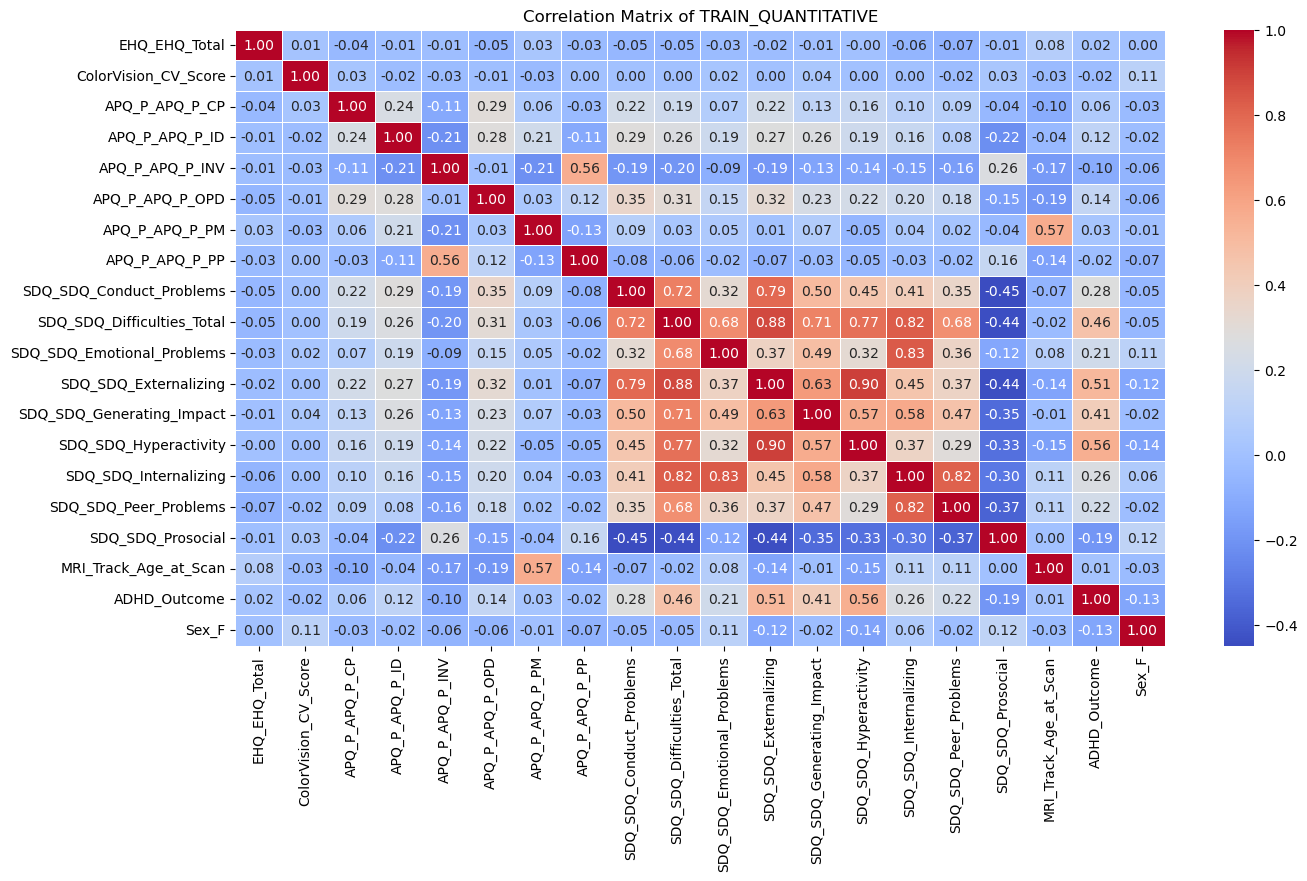

In [45]:
corr = merged_df.drop(['participant_id'],axis=1).corr()
plt.figure(figsize=(15, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of TRAIN_QUANTITATIVE")
plt.show()

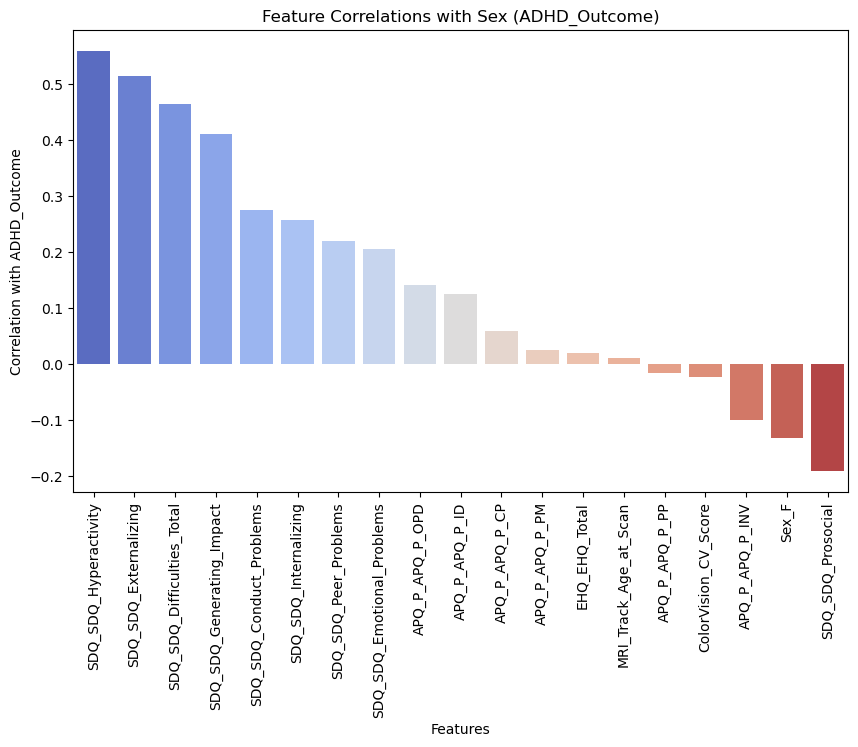

In [46]:
# Extract correlations of features with respect to 'ADHD_Outcome'
correlation_with_sex = corr['ADHD_Outcome'].drop('ADHD_Outcome').sort_values(ascending=False)

# Plot the correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_with_sex.index, y=correlation_with_sex.values, palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Correlation with ADHD_Outcome")
plt.title("Feature Correlations with Sex (ADHD_Outcome)")
plt.show()

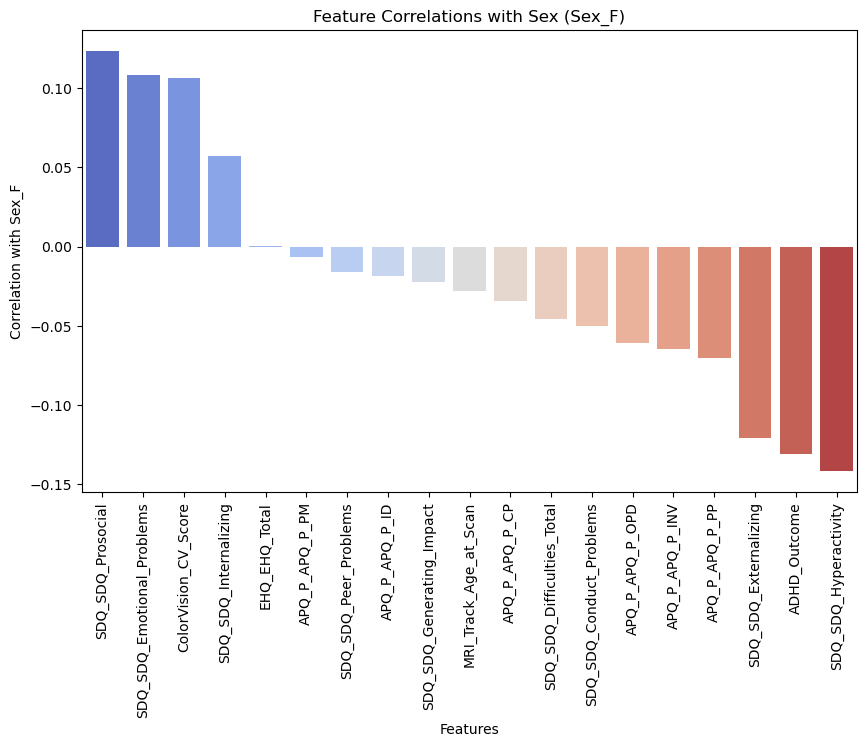

In [47]:
# Extract correlations of features with respect to 'Sex_F'
correlation_with_sex = corr['Sex_F'].drop('Sex_F').sort_values(ascending=False)

# Plot the correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_with_sex.index, y=correlation_with_sex.values, palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Correlation with Sex_F")
plt.title("Feature Correlations with Sex (Sex_F)")
plt.show()

### Distribution of Numeric column

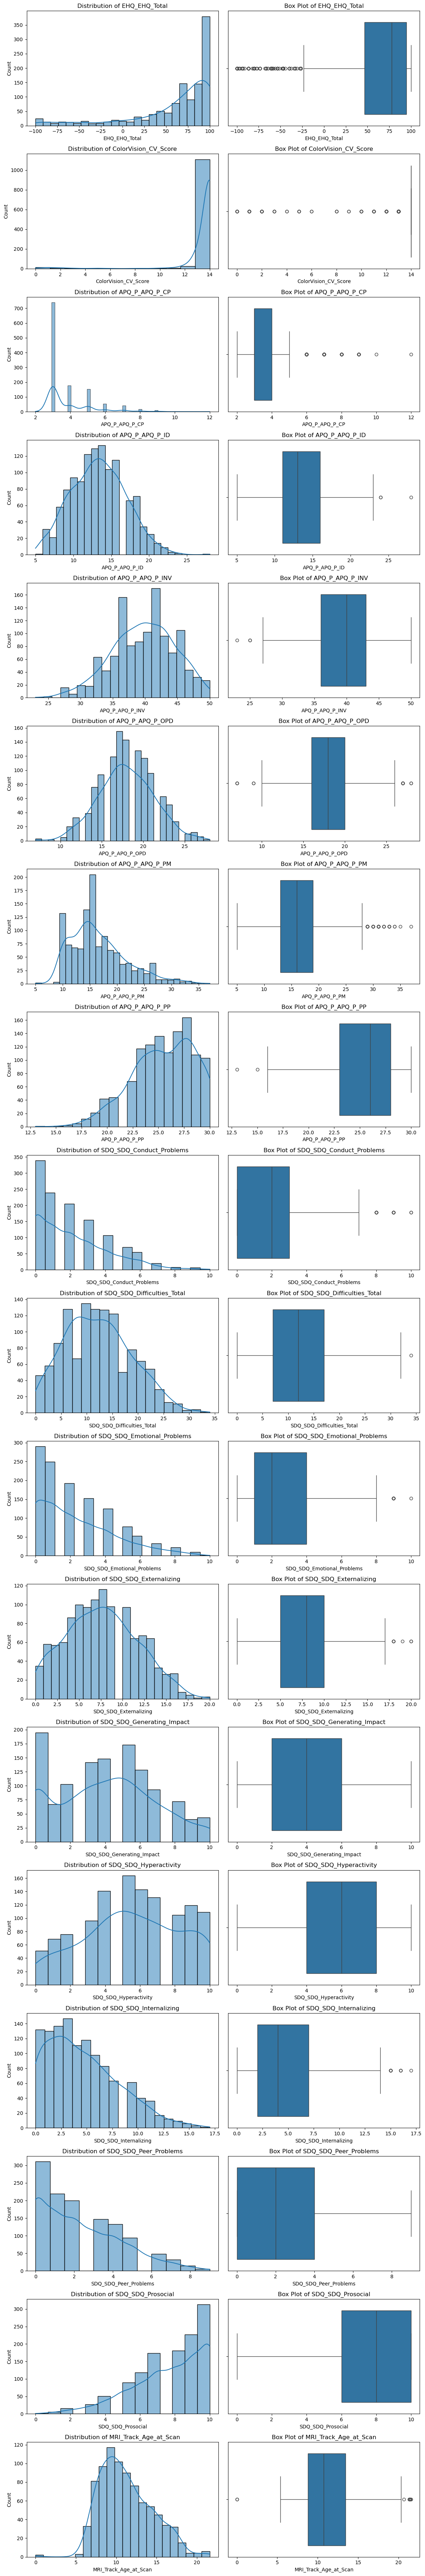

In [49]:
numeric_df = TRAIN_QUANTITATIVE.select_dtypes(include=['float64', 'int64'])
num_columns = len(numeric_df.columns)  
fig, axes = plt.subplots(num_columns, 2, figsize=(12, num_columns * 4))  # 2 subplots (distribution and boxplot) for each column

for i, column in enumerate(numeric_df.columns):
    # Distribution Plot
    sns.histplot(numeric_df[column], ax=axes[i, 0], kde=True)  # kde=True adds a kernel density estimate (smoothed curve)
    axes[i, 0].set_title(f'Distribution of {column}')

    # Box Plot
    sns.boxplot(x=numeric_df[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Box Plot of {column}')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

# Pre-processing

## Missing data

### TRAIN_QUANTITATIVE

In [53]:
get_messing(TRAIN_QUANTITATIVE)

,Count,%
participant_id,0,0.00
EHQ_EHQ_Total,13,1.07
ColorVision_CV_Score,23,1.90
APQ_P_APQ_P_CP,12,0.99
APQ_P_APQ_P_ID,12,0.99
APQ_P_APQ_P_INV,12,0.99
APQ_P_APQ_P_OPD,12,0.99
APQ_P_APQ_P_PM,12,0.99
APQ_P_APQ_P_PP,12,0.99
SDQ_SDQ_Conduct_Problems,9,0.74


Those are only the columns with missing data

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import pandas as pd

# Step 1: Separate participant_id
ids = TRAIN_QUANTITATIVE['participant_id']
data = TRAIN_QUANTITATIVE.drop(columns=['participant_id'])

# Step 2: Scale and Impute
scaler = StandardScaler()
scaled = scaler.fit_transform(data)

imputer = KNNImputer(n_neighbors=5)
filled = imputer.fit_transform(scaled)

# Step 3: Reconstruct the DataFrame
data_imputed = pd.DataFrame(scaler.inverse_transform(filled), columns=data.columns)

# Step 4: Add participant_id back
TRAIN_QUANTITATIVE_imputed = pd.concat([ids.reset_index(drop=True), data_imputed], axis=1)
TRAIN_QUANTITATIVE_imputed


,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,00aIpNTbG5uh,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,17.0,4.000000e+00,11.0,5.0,8.0,6.0,2.0,9.0,14.274127
1,00fV0OyyoLfw,92.27,14.0,3.0,12.0,35.0,25.0,28.0,30.0,5.0,20.0,4.000000e+00,13.0,5.0,8.0,7.0,3.0,8.0,13.340269
2,04X1eiS79T4B,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,24.0,7.000000e+00,10.0,10.0,7.0,14.0,7.0,7.0,13.463381
3,05ocQutkURd6,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,5.0,-4.440892e-16,3.0,0.0,3.0,2.0,2.0,6.0,9.572553
4,06YUNBA9ZRLq,0.00,14.0,8.0,12.0,35.0,22.0,12.0,24.0,6.0,23.0,7.000000e+00,15.0,8.0,9.0,8.0,1.0,4.0,6.654574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,zpU7rEseBMH8,100.00,14.0,3.0,11.0,41.0,16.0,23.0,24.0,0.0,8.0,-4.440892e-16,6.0,6.0,6.0,2.0,2.0,8.0,12.669860
1209,zpr8w4jCfVPe,100.00,14.0,3.0,9.0,41.0,22.0,10.0,29.0,1.0,15.0,3.000000e+00,8.0,3.0,7.0,7.0,4.0,7.0,9.622815
1210,zwBG0rZ05Mcb,46.67,13.0,3.0,12.0,30.0,18.0,14.0,24.0,0.0,10.0,3.000000e+00,5.0,3.0,5.0,5.0,2.0,8.0,8.155258
1211,zwXD5v17Rx01,46.67,14.0,3.0,18.0,42.0,21.0,15.0,25.0,2.0,5.0,-4.440892e-16,5.0,0.0,3.0,0.0,0.0,7.0,7.364020


In [56]:
TRAIN_QUANTITATIVE

,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,00aIpNTbG5uh,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,17.0,4.0,11.0,5.0,8.0,6.0,2.0,9.0,14.274127
1,00fV0OyyoLfw,92.27,14.0,3.0,12.0,35.0,25.0,28.0,30.0,5.0,20.0,4.0,13.0,5.0,8.0,7.0,3.0,8.0,NaN
2,04X1eiS79T4B,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,24.0,7.0,10.0,10.0,7.0,14.0,7.0,7.0,13.463381
3,05ocQutkURd6,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,5.0,0.0,3.0,0.0,3.0,2.0,2.0,6.0,9.572553
4,06YUNBA9ZRLq,0.00,14.0,8.0,12.0,35.0,22.0,12.0,24.0,6.0,23.0,7.0,15.0,8.0,9.0,8.0,1.0,4.0,6.654574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,zpU7rEseBMH8,100.00,14.0,3.0,11.0,41.0,16.0,23.0,24.0,0.0,8.0,0.0,6.0,6.0,6.0,2.0,2.0,8.0,12.669860
1209,zpr8w4jCfVPe,100.00,14.0,3.0,9.0,41.0,22.0,10.0,29.0,1.0,15.0,3.0,8.0,3.0,7.0,7.0,4.0,7.0,NaN
1210,zwBG0rZ05Mcb,46.67,13.0,3.0,12.0,30.0,18.0,14.0,24.0,0.0,10.0,3.0,5.0,3.0,5.0,5.0,2.0,8.0,8.155258
1211,zwXD5v17Rx01,46.67,14.0,3.0,18.0,42.0,21.0,15.0,25.0,2.0,5.0,0.0,5.0,0.0,3.0,0.0,0.0,7.0,7.364020


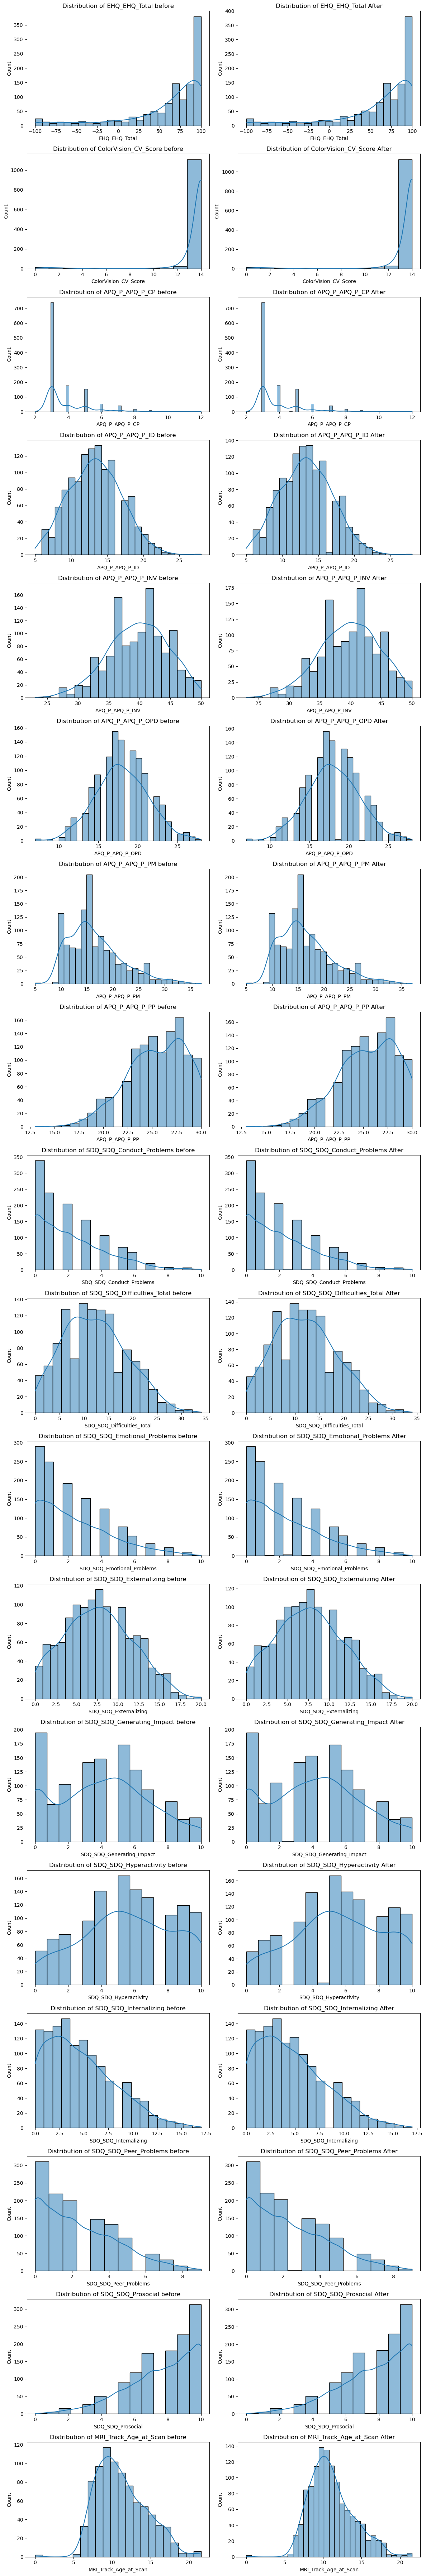

In [57]:
numeric_df = TRAIN_QUANTITATIVE.select_dtypes(include=['float64', 'int64'])
numeric_df_imputed = TRAIN_QUANTITATIVE_imputed.select_dtypes(include=['float64', 'int64'])

num_columns = len(numeric_df.columns)  
fig, axes = plt.subplots(num_columns, 2, figsize=(12, num_columns * 4))  # 2 subplots (distribution and boxplot) for each column

for i, column in enumerate(numeric_df.columns):
    # Distribution Plot before
    sns.histplot(numeric_df[column], ax=axes[i, 0], kde=True)  # kde=True adds a kernel density estimate (smoothed curve)
    axes[i, 0].set_title(f'Distribution of {column} before')

    # Distribution Plot After
    sns.histplot(numeric_df_imputed[column], ax=axes[i, 1], kde=True)  # kde=True adds a kernel density estimate (smoothed curve)
    axes[i, 1].set_title(f'Distribution of {column} After')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

In [58]:
get_messing(TRAIN_QUANTITATIVE_imputed)

No Messing Data


### TRAIN_CATEGORICAL

In [60]:
get_messing(TRAIN_CATEGORICAL)

,Count,%
participant_id,0,0.00
Basic_Demos_Enroll_Year,0,0.00
Basic_Demos_Study_Site,0,0.00
PreInt_Demos_Fam_Child_Ethnicity,43,3.54
PreInt_Demos_Fam_Child_Race,54,4.45
MRI_Track_Scan_Location,3,0.25
Barratt_Barratt_P1_Edu,15,1.24
Barratt_Barratt_P1_Occ,31,2.56
Barratt_Barratt_P2_Edu,198,16.32
Barratt_Barratt_P2_Occ,222,18.30


In [61]:
TRAIN_CATEGORICAL.head()

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
0,00aIpNTbG5uh,2019,4,1.0,0.0,3.0,21.0,45.0,NaN,NaN
1,00fV0OyyoLfw,2017,1,0.0,9.0,2.0,21.0,0.0,21.0,45.0
2,04X1eiS79T4B,2017,1,1.0,2.0,2.0,9.0,0.0,NaN,NaN
3,05ocQutkURd6,2018,1,3.0,8.0,2.0,18.0,10.0,18.0,0.0
4,06YUNBA9ZRLq,2018,1,0.0,1.0,2.0,12.0,0.0,NaN,NaN


In [62]:
TRAIN_CATEGORICAL[['Basic_Demos_Study_Site','MRI_Track_Scan_Location']]

,Basic_Demos_Study_Site,MRI_Track_Scan_Location
0,4,3.0
1,1,2.0
2,1,2.0
3,1,2.0
4,1,2.0
...,...,...
1208,1,2.0
1209,3,3.0
1210,1,2.0
1211,1,3.0


In [63]:
TRAIN_CATEGORICAL[TRAIN_CATEGORICAL['MRI_Track_Scan_Location'].isna()]

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
585,UmN79UUheNpw,2016,1,0.0,0.0,NaN,21.0,25.0,18.0,45.0
1155,x0yuhCZiG4mU,2016,1,0.0,0.0,NaN,18.0,40.0,18.0,45.0
1201,zSOTbT8r7FQ2,2016,1,0.0,NaN,NaN,15.0,0.0,21.0,35.0


In [64]:
TRAIN_CATEGORICAL_imputed = TRAIN_CATEGORICAL.copy()
TRAIN_CATEGORICAL_imputed['MRI_Track_Scan_Location'] = TRAIN_CATEGORICAL.groupby(['Basic_Demos_Enroll_Year', 'Basic_Demos_Study_Site'])['MRI_Track_Scan_Location']\
        .transform(lambda x: x.fillna(x.mode()[0]))  
TRAIN_CATEGORICAL_imputed.iloc[[585, 1155, 1201]]

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
585,UmN79UUheNpw,2016,1,0.0,0.0,1.0,21.0,25.0,18.0,45.0
1155,x0yuhCZiG4mU,2016,1,0.0,0.0,1.0,18.0,40.0,18.0,45.0
1201,zSOTbT8r7FQ2,2016,1,0.0,NaN,1.0,15.0,0.0,21.0,35.0


In [65]:
get_messing(TRAIN_CATEGORICAL_imputed)

,Count,%
participant_id,0,0.00
Basic_Demos_Enroll_Year,0,0.00
Basic_Demos_Study_Site,0,0.00
PreInt_Demos_Fam_Child_Ethnicity,43,3.54
PreInt_Demos_Fam_Child_Race,54,4.45
MRI_Track_Scan_Location,0,0.00
Barratt_Barratt_P1_Edu,15,1.24
Barratt_Barratt_P1_Occ,31,2.56
Barratt_Barratt_P2_Edu,198,16.32
Barratt_Barratt_P2_Occ,222,18.30


In [66]:
col_to_impute = ['Barratt_Barratt_P1_Occ','Barratt_Barratt_P2_Edu','Barratt_Barratt_P2_Occ']
for col in col_to_impute:
    TRAIN_CATEGORICAL_imputed[col] = TRAIN_CATEGORICAL_imputed.groupby(
        ['Basic_Demos_Study_Site','Barratt_Barratt_P1_Edu']
    )[col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
get_messing(TRAIN_CATEGORICAL_imputed,drop=True) 

,Count,%
PreInt_Demos_Fam_Child_Ethnicity,43.0,3.54
PreInt_Demos_Fam_Child_Race,54.0,4.45
Barratt_Barratt_P1_Edu,15.0,1.24
Barratt_Barratt_P1_Occ,15.0,1.24
Barratt_Barratt_P2_Edu,19.0,1.57
Barratt_Barratt_P2_Occ,19.0,1.57


In [67]:
from sklearn.impute import SimpleImputer
cols = get_messing(TRAIN_CATEGORICAL_imputed,drop=True).index.tolist()
imputer = SimpleImputer(strategy='most_frequent')
TRAIN_CATEGORICAL_imputed[cols] = imputer.fit_transform(TRAIN_CATEGORICAL_imputed[cols])
get_messing(TRAIN_CATEGORICAL_imputed,drop=True) 

No Messing Data


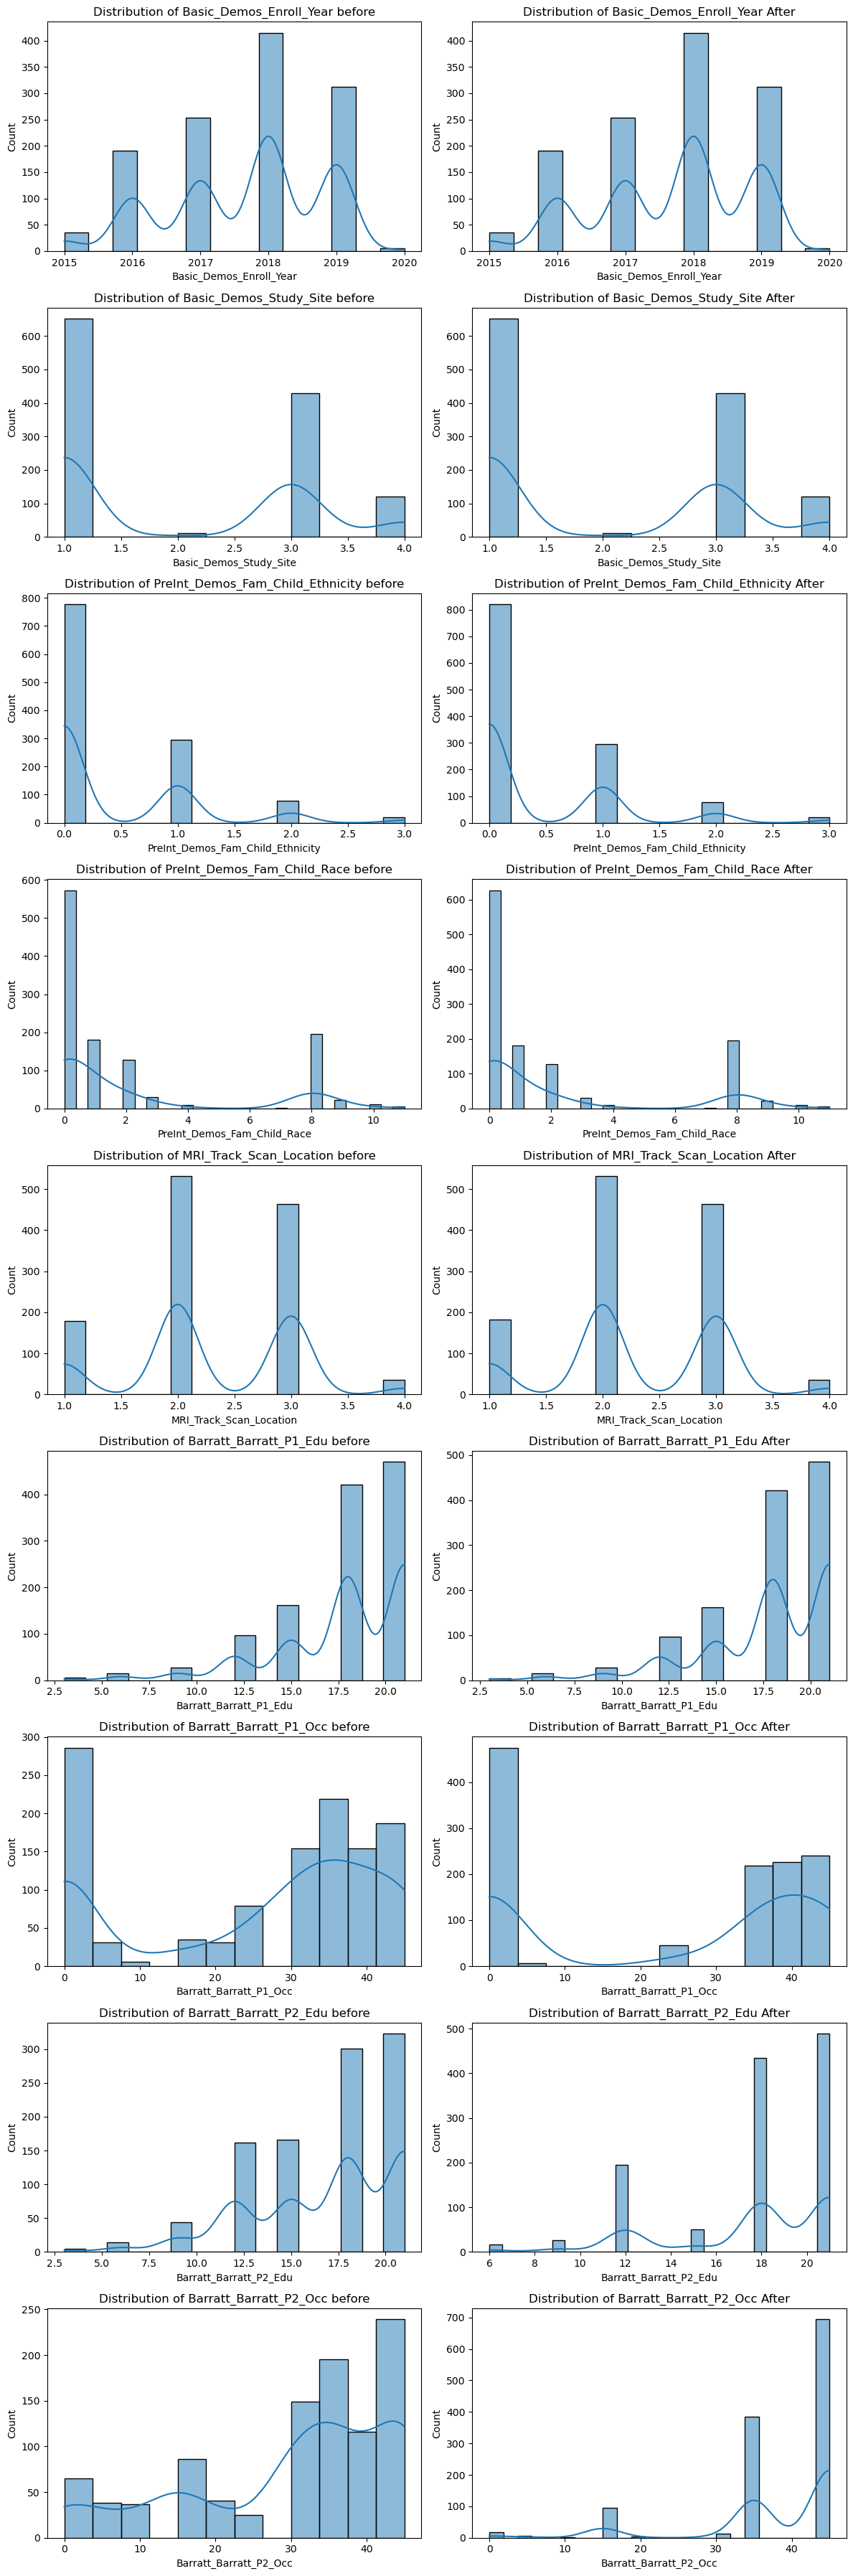

In [68]:
numeric_df = TRAIN_CATEGORICAL.select_dtypes(include=['float64', 'int64'])
numeric_df_imputed = TRAIN_CATEGORICAL_imputed.select_dtypes(include=['float64', 'int64'])

num_columns = len(numeric_df.columns)  
fig, axes = plt.subplots(num_columns, 2, figsize=(12, num_columns * 4))  # 2 subplots (distribution and boxplot) for each column

for i, column in enumerate(numeric_df.columns):
    # Distribution Plot before
    sns.histplot(numeric_df[column], ax=axes[i, 0], kde=True)  # kde=True adds a kernel density estimate (smoothed curve)
    axes[i, 0].set_title(f'Distribution of {column} before')

    # Distribution Plot After
    sns.histplot(numeric_df_imputed[column], ax=axes[i, 1], kde=True)  # kde=True adds a kernel density estimate (smoothed curve)
    axes[i, 1].set_title(f'Distribution of {column} After')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

## Outliers

In [70]:
numeric_df=TRAIN_QUANTITATIVE_imputed.select_dtypes(include=['float64', 'int64'])
Outliers=numeric_df.columns.tolist()
print(len(Outliers))
Outliers

18


['EHQ_EHQ_Total',
 'ColorVision_CV_Score',
 'APQ_P_APQ_P_CP',
 'APQ_P_APQ_P_ID',
 'APQ_P_APQ_P_INV',
 'APQ_P_APQ_P_OPD',
 'APQ_P_APQ_P_PM',
 'APQ_P_APQ_P_PP',
 'SDQ_SDQ_Conduct_Problems',
 'SDQ_SDQ_Difficulties_Total',
 'SDQ_SDQ_Emotional_Problems',
 'SDQ_SDQ_Externalizing',
 'SDQ_SDQ_Generating_Impact',
 'SDQ_SDQ_Hyperactivity',
 'SDQ_SDQ_Internalizing',
 'SDQ_SDQ_Peer_Problems',
 'SDQ_SDQ_Prosocial',
 'MRI_Track_Age_at_Scan']

In [71]:
df = handel_Outliers(numeric_df,Outliers,handel=True)

EHQ_EHQ_Total  : 

IQR = 46.730000000000004
lower,upper bounds [-23.424999999999997,163.495]
Total number of outliers in EHQ_EHQ_Total are 110
ColorVision_CV_Score  : 

IQR = 0.0
lower,upper bounds [14.0,14.0]
Total number of outliers in ColorVision_CV_Score are 234
APQ_P_APQ_P_CP  : 

IQR = 1.0
lower,upper bounds [1.5,5.5]
Total number of outliers in APQ_P_APQ_P_CP are 128
APQ_P_APQ_P_ID  : 

IQR = 5.0
lower,upper bounds [3.5,23.5]
Total number of outliers in APQ_P_APQ_P_ID are 3
APQ_P_APQ_P_INV  : 

IQR = 7.0
lower,upper bounds [25.5,53.5]
Total number of outliers in APQ_P_APQ_P_INV are 3
APQ_P_APQ_P_OPD  : 

IQR = 4.0
lower,upper bounds [10.0,26.0]
Total number of outliers in APQ_P_APQ_P_OPD are 13
APQ_P_APQ_P_PM  : 

IQR = 6.0
lower,upper bounds [4.0,28.0]
Total number of outliers in APQ_P_APQ_P_PM are 37
APQ_P_APQ_P_PP  : 

IQR = 5.0
lower,upper bounds [15.5,35.5]
Total number of outliers in APQ_P_APQ_P_PP are 2
SDQ_SDQ_Conduct_Problems  : 

IQR = 3.0
lower,upper bounds [-4.5,7.5]

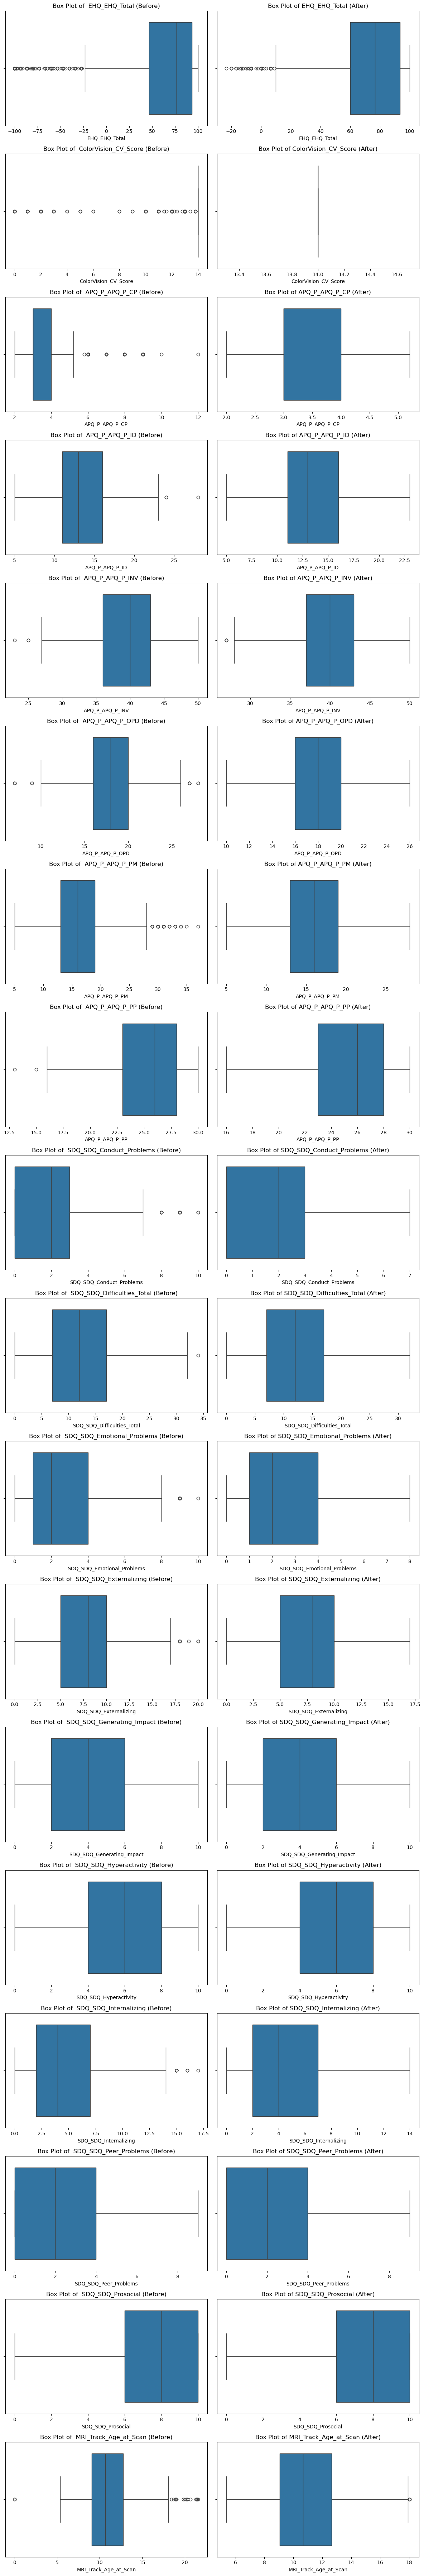

In [72]:
df_old = TRAIN_QUANTITATIVE_imputed.copy()
num_columns = len(Outliers)  # Number of columns in your DataFrame
fig, axes = plt.subplots(num_columns, 2, figsize=(12, num_columns * 4))  # 2 subplots (distribution and boxplot) for each column

# Loop through each column to create distribution and boxplot
for i, column in enumerate(Outliers):
    # Before
    sns.boxplot(x=df_old[column], ax=axes[i, 0])  # kde=True adds a kernel density estimate (smoothed curve)
    axes[i, 0].set_title(f'Box Plot of  {column} (Before)')

    # After
    sns.boxplot(x=df[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Box Plot of {column} (After)')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

## Feature Reduction

### TRAIN_FUNCTIONAL_CONNECTOME_MATRICES

In [75]:
df = TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.iloc[:,1:]
df

,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,0throw_10thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,0.361339,0.791402,0.530706,0.623133,0.845830,0.680234,0.537144,0.387455,0.498571,0.049068,...,-0.047477,-0.096450,-0.280312,0.037560,0.423037,0.242453,0.336213,0.402338,0.327915,0.539032
1,0.051430,0.613198,0.635255,0.391237,0.451225,0.600475,0.420935,0.234825,0.322048,0.181864,...,-0.143218,-0.276464,-0.332783,-0.332711,0.556939,0.475578,0.429196,0.457970,0.312571,0.595978
2,-0.305747,0.750316,-0.005342,0.458421,0.757530,0.756288,0.799046,0.622567,0.659165,0.519783,...,-0.133778,-0.108588,-0.002132,-0.175586,0.679183,0.290292,0.486680,0.255208,0.575017,0.605182
3,0.450442,0.731530,0.799147,0.701688,0.747468,0.523304,0.575033,0.187189,0.441150,-0.004607,...,-0.096647,-0.041420,-0.199576,-0.216457,0.519074,0.298586,0.415466,0.511607,0.361204,0.446613
4,0.415220,0.585700,0.355835,0.664142,0.683491,0.380201,0.375091,0.212314,0.445294,0.226854,...,-0.158995,-0.274017,-0.141012,-0.002865,0.515169,0.336139,0.316430,0.442230,0.177079,0.378278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,-0.017270,0.856987,0.827741,0.548133,0.800407,0.574002,0.798349,0.284567,0.155855,0.435824,...,0.156577,-0.233931,-0.140041,-0.183657,0.253419,0.520024,0.337320,0.629728,0.678281,0.814656
1209,0.342895,0.653258,0.691103,0.271458,0.593868,0.516559,0.360994,0.140348,0.062568,-0.025561,...,-0.039988,-0.087121,-0.049484,-0.119850,0.610159,0.570343,0.303530,0.850718,0.725138,0.721350
1210,0.251472,0.692684,0.544077,0.622913,0.658320,0.481675,0.476222,0.293739,0.368002,0.236086,...,-0.126600,-0.393645,-0.074682,-0.204213,0.370247,0.238742,0.131456,0.472743,0.588147,0.418452
1211,-0.045660,0.207386,-0.140892,0.053852,0.204124,0.479489,0.333045,0.239930,0.314171,0.219034,...,0.343204,0.198827,0.253990,0.198741,0.648260,0.055241,0.491985,0.118676,0.404331,0.537121


**What is "Explained Variance" in PCA?**\
When you apply PCA, you're transforming your original data (maybe hundreds or thousands of features) into a new set of principal components (PCs).\
Each PC captures a portion of the total variance (i.e. the "spread" or information) in the data.

- Explained Variance = How much variation in the data is captured by a single principal component.

- Cumulative Explained Variance = The total variance captured up to that component (e.g. PC1 + PC2 + PC3...).

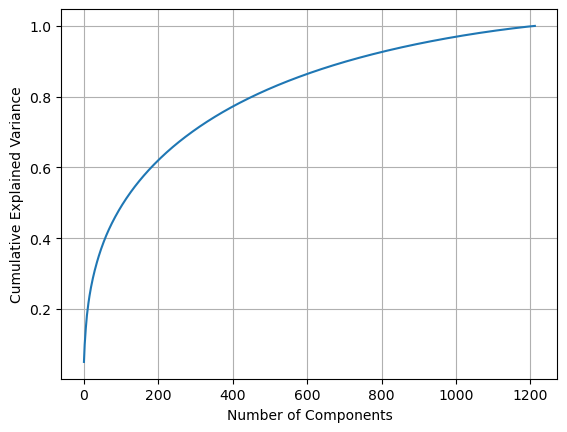

In [77]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca = PCA().fit(df)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()


In [78]:
pca = PCA(n_components=0.75)  # Keep 75% of the variance
reduced_data = pca.fit_transform(TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.iloc[:,1:])
reduced_data.shape

(1213, 364)

In [79]:
pca_columns = [f'PC_{i+1}' for i in range(reduced_data.shape[1])]

# Convert to DataFrame
reduced_df = pd.DataFrame(reduced_data, columns=pca_columns)
reduced_df['participant_id'] = TRAIN_FUNCTIONAL_CONNECTOME_MATRICES['participant_id']
reduced_df

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_356,PC_357,PC_358,PC_359,PC_360,PC_361,PC_362,PC_363,PC_364,participant_id
0,-5.367968,-5.068500,1.508765,2.062678,0.697009,-0.371967,-2.574856,-1.824426,-2.881217,2.042189,...,0.345860,1.087942,0.109700,0.292312,0.890052,0.753054,0.866334,-0.039000,-0.646595,00aIpNTbG5uh
1,-4.108815,-3.920926,0.070828,1.683232,-1.204590,1.199795,-0.275150,0.007479,0.797247,-1.207645,...,-0.024119,0.057152,-0.444152,-0.909778,-0.889040,-0.481209,-0.121824,-0.139141,0.888230,00fV0OyyoLfw
2,-5.987513,-5.386339,2.510001,-3.763229,1.955189,-1.496322,-2.904989,2.163707,3.292545,-0.556093,...,0.027687,0.176502,0.073532,0.393167,-0.581019,0.262587,-1.334529,-0.765048,-1.327679,04X1eiS79T4B
3,-3.775851,-6.756400,0.928621,3.646527,-3.212114,-0.677817,-2.633906,-0.383115,-0.332242,2.460489,...,-0.083967,0.197136,-0.253405,1.529146,0.106747,-0.154228,-1.114315,-0.283471,0.295437,05ocQutkURd6
4,1.979975,-4.088958,-3.459130,3.523769,-0.906082,-0.608358,-5.656954,3.202955,2.225541,1.825331,...,0.698973,0.078269,0.077646,-1.116435,0.242452,0.105067,0.743776,0.500913,-0.136221,06YUNBA9ZRLq
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,-6.437288,-6.021686,3.898046,1.085205,2.015552,-1.540975,1.796908,-1.266181,-2.146448,-0.011019,...,0.255708,0.484907,-1.269529,-0.523940,0.284541,0.492671,-0.294945,-1.000375,-0.808391,zpU7rEseBMH8
1209,7.206823,-3.618114,6.848007,0.609650,0.508437,-1.183881,6.298111,-1.214415,3.531693,-3.756891,...,-0.037189,0.255253,-0.847075,-0.276575,1.314789,-0.381803,0.461827,-0.809201,-0.207979,zpr8w4jCfVPe
1210,0.840310,-4.220060,-0.619828,0.337278,2.806762,0.060692,2.065328,0.877024,-1.137559,-0.081301,...,-0.362322,0.057298,-0.013778,0.326770,-0.230251,0.262517,0.142389,0.345846,-0.256849,zwBG0rZ05Mcb
1211,9.373537,4.577333,1.337234,-5.033227,1.456240,-1.564184,1.469079,-0.607567,-2.958979,-2.511220,...,-0.694270,-0.470455,-1.366640,-0.486149,0.760492,-0.129692,-0.620907,-1.589824,2.241099,zwXD5v17Rx01


## Merging

In [81]:
merged_df = pd.merge(TRAIN_QUANTITATIVE_imputed, TRAIN_CATEGORICAL_imputed, on='participant_id', how='inner')
tmp = pd.merge(merged_df, reduced_df, on='participant_id', how='inner')
data = pd.merge(tmp, TRAINING_SOLUTIONS, on='participant_id', how='inner')

In [82]:
data.head()

,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,...,PC_357,PC_358,PC_359,PC_360,PC_361,PC_362,PC_363,PC_364,ADHD_Outcome,Sex_F
0,00aIpNTbG5uh,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,...,1.087942,0.109700,0.292312,0.890052,0.753054,0.866334,-0.039000,-0.646595,1,0
1,00fV0OyyoLfw,92.27,14.0,3.0,12.0,35.0,25.0,28.0,30.0,5.0,...,0.057152,-0.444152,-0.909778,-0.889040,-0.481209,-0.121824,-0.139141,0.888230,1,0
2,04X1eiS79T4B,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,...,0.176502,0.073532,0.393167,-0.581019,0.262587,-1.334529,-0.765048,-1.327679,0,1
3,05ocQutkURd6,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,...,0.197136,-0.253405,1.529146,0.106747,-0.154228,-1.114315,-0.283471,0.295437,0,1
4,06YUNBA9ZRLq,0.00,14.0,8.0,12.0,35.0,22.0,12.0,24.0,6.0,...,0.078269,0.077646,-1.116435,0.242452,0.105067,0.743776,0.500913,-0.136221,1,0


## Re-indexing

In [84]:
data = data.set_index('participant_id').sort_index()
data.head()

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,...,PC_357,PC_358,PC_359,PC_360,PC_361,PC_362,PC_363,PC_364,ADHD_Outcome,Sex_F
participant_id,,,,,,,,,,,,,,,,,,,,,
00aIpNTbG5uh,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,17.0,...,1.087942,0.109700,0.292312,0.890052,0.753054,0.866334,-0.039000,-0.646595,1,0
00fV0OyyoLfw,92.27,14.0,3.0,12.0,35.0,25.0,28.0,30.0,5.0,20.0,...,0.057152,-0.444152,-0.909778,-0.889040,-0.481209,-0.121824,-0.139141,0.888230,1,0
04X1eiS79T4B,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,24.0,...,0.176502,0.073532,0.393167,-0.581019,0.262587,-1.334529,-0.765048,-1.327679,0,1
05ocQutkURd6,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,5.0,...,0.197136,-0.253405,1.529146,0.106747,-0.154228,-1.114315,-0.283471,0.295437,0,1
06YUNBA9ZRLq,0.00,14.0,8.0,12.0,35.0,22.0,12.0,24.0,6.0,23.0,...,0.078269,0.077646,-1.116435,0.242452,0.105067,0.743776,0.500913,-0.136221,1,0


## Scaling

In [86]:
X = data.iloc[:,:-2]
X.head()

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,...,PC_355,PC_356,PC_357,PC_358,PC_359,PC_360,PC_361,PC_362,PC_363,PC_364
participant_id,,,,,,,,,,,,,,,,,,,,,
00aIpNTbG5uh,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,17.0,...,1.188651,0.345860,1.087942,0.109700,0.292312,0.890052,0.753054,0.866334,-0.039000,-0.646595
00fV0OyyoLfw,92.27,14.0,3.0,12.0,35.0,25.0,28.0,30.0,5.0,20.0,...,0.143352,-0.024119,0.057152,-0.444152,-0.909778,-0.889040,-0.481209,-0.121824,-0.139141,0.888230
04X1eiS79T4B,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,24.0,...,0.763875,0.027687,0.176502,0.073532,0.393167,-0.581019,0.262587,-1.334529,-0.765048,-1.327679
05ocQutkURd6,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,5.0,...,-1.202050,-0.083967,0.197136,-0.253405,1.529146,0.106747,-0.154228,-1.114315,-0.283471,0.295437
06YUNBA9ZRLq,0.00,14.0,8.0,12.0,35.0,22.0,12.0,24.0,6.0,23.0,...,0.156976,0.698973,0.078269,0.077646,-1.116435,0.242452,0.105067,0.743776,0.500913,-0.136221


In [87]:
y = data.iloc[:,-2:]
y.head()

,ADHD_Outcome,Sex_F
participant_id,,
00aIpNTbG5uh,1,0
00fV0OyyoLfw,1,0
04X1eiS79T4B,0,1
05ocQutkURd6,0,1
06YUNBA9ZRLq,1,0


In [88]:
scaler = StandardScaler()
X_scaled = StandardScaler().fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Train-Test-Split

In [90]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42)
print(f"X_train.shape {X_train.shape}          y_train.shape {y_train.shape} ")
print(f"X_test.shape {X_test.shape}            y_test.shape {y_test.shape} ")

X_train.shape (849, 391)          y_train.shape (849, 2) 
X_test.shape (364, 391)            y_test.shape (364, 2) 


# Models

In [374]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import GridSearchCV
import joblib
import time
import os
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier

## KNN

In [376]:
knn = KNeighborsClassifier()
multi_knn = MultiOutputClassifier(knn)

In [377]:
k_values = list(range(1,20))
param_grid = {
    'estimator__n_neighbors': k_values,
    'estimator__weights': ['uniform', 'distance'],
    'estimator__p': [1, 2]  # p=1 for Manhattan, p=2 for Euclidean
}

### accuracy

In [379]:
grid_search = GridSearchCV(multi_knn, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)

In [380]:
# Specify the file path where the grid search results are saved
file_path = "Models/(grid_search)multi_knn_scoring=accuracy.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model exists
Model loaded


In [381]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=KNeighborsClassifier(n_neighbors=17, p=1))

In [382]:
best_model.get_params()

{'estimator__algorithm': 'auto',
 'estimator__leaf_size': 30,
 'estimator__metric': 'minkowski',
 'estimator__metric_params': None,
 'estimator__n_jobs': None,
 'estimator__n_neighbors': 17,
 'estimator__p': 1,
 'estimator__weights': 'uniform',
 'estimator': KNeighborsClassifier(n_neighbors=17, p=1),
 'n_jobs': None}

In [383]:
print("Best score:", grid_search.best_score_)

Best score: 0.33215547703180215


In [384]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.42      0.91      0.57       121
           1       0.89      0.37      0.53       243

    accuracy                           0.55       364
   macro avg       0.66      0.64      0.55       364
weighted avg       0.74      0.55      0.54       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.71      0.91      0.80       254
           1       0.39      0.13      0.19       110

    accuracy                           0.68       364
   macro avg       0.55      0.52      0.49       364
weighted avg       0.61      0.68      0.61       364



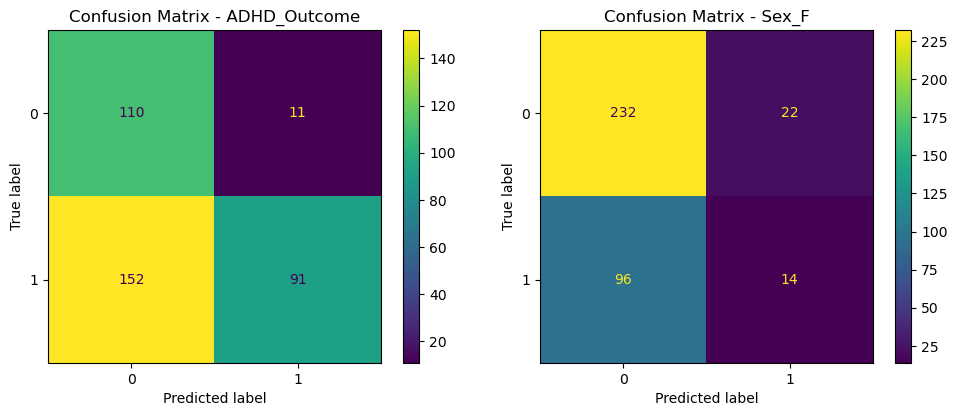

In [385]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

### multi_output_scorer

In [387]:
grid_search = GridSearchCV(multi_knn, param_grid, cv=3, scoring=multi_output_scorer, n_jobs=-1, verbose=2)

In [388]:
# Specify the file path where the grid search results are saved
file_path = "Models/(grid_search)multi_knn_scoring=multi_output_scorer.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model exists
Model loaded


In [389]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                       max_depth=3,
                                                       random_state=42))

In [390]:
best_model.get_params()

{'estimator__ccp_alpha': 0.0,
 'estimator__class_weight': None,
 'estimator__criterion': 'entropy',
 'estimator__max_depth': 3,
 'estimator__max_features': None,
 'estimator__max_leaf_nodes': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__monotonic_cst': None,
 'estimator__random_state': 42,
 'estimator__splitter': 'best',
 'estimator': DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42),
 'n_jobs': None}

In [391]:
print("Best score:", grid_search.best_score_)

Best score: 0.702002355712603


In [392]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.69      0.60      0.64       121
           1       0.81      0.87      0.84       243

    accuracy                           0.78       364
   macro avg       0.75      0.73      0.74       364
weighted avg       0.77      0.78      0.77       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.70      1.00      0.82       254
           1       0.67      0.02      0.04       110

    accuracy                           0.70       364
   macro avg       0.68      0.51      0.43       364
weighted avg       0.69      0.70      0.58       364



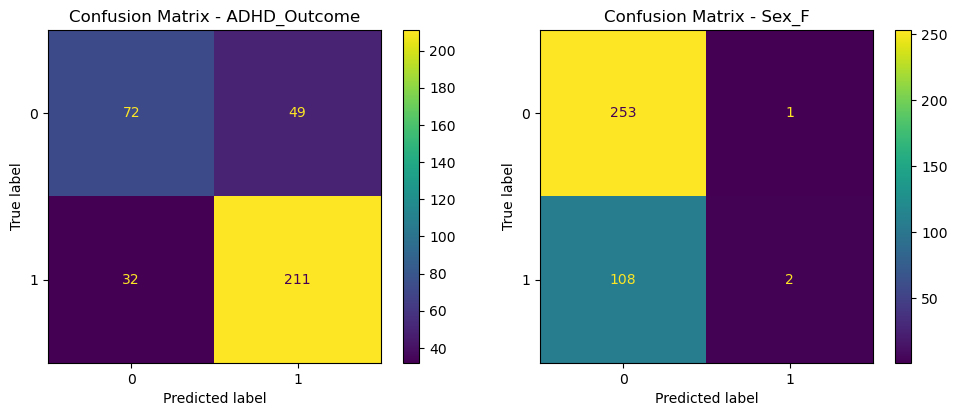

In [393]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

### F1 Score

In [395]:
grid_search = GridSearchCV(multi_knn, param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=2)

In [396]:
# Specify the file path where the grid search results are saved
file_path = "Models/(grid_search)multi_knn_scoring=f1_macro.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model exists
Model loaded


In [397]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=KNeighborsClassifier(n_neighbors=1, p=1))

In [398]:
best_model.get_params()

{'estimator__algorithm': 'auto',
 'estimator__leaf_size': 30,
 'estimator__metric': 'minkowski',
 'estimator__metric_params': None,
 'estimator__n_jobs': None,
 'estimator__n_neighbors': 1,
 'estimator__p': 1,
 'estimator__weights': 'uniform',
 'estimator': KNeighborsClassifier(n_neighbors=1, p=1),
 'n_jobs': None}

In [399]:
print("Best score:", grid_search.best_score_)

Best score: 0.4285598549701439


In [400]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.38      0.82      0.52       121
           1       0.79      0.34      0.48       243

    accuracy                           0.50       364
   macro avg       0.59      0.58      0.50       364
weighted avg       0.65      0.50      0.49       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.70      0.79      0.74       254
           1       0.32      0.23      0.26       110

    accuracy                           0.62       364
   macro avg       0.51      0.51      0.50       364
weighted avg       0.59      0.62      0.60       364



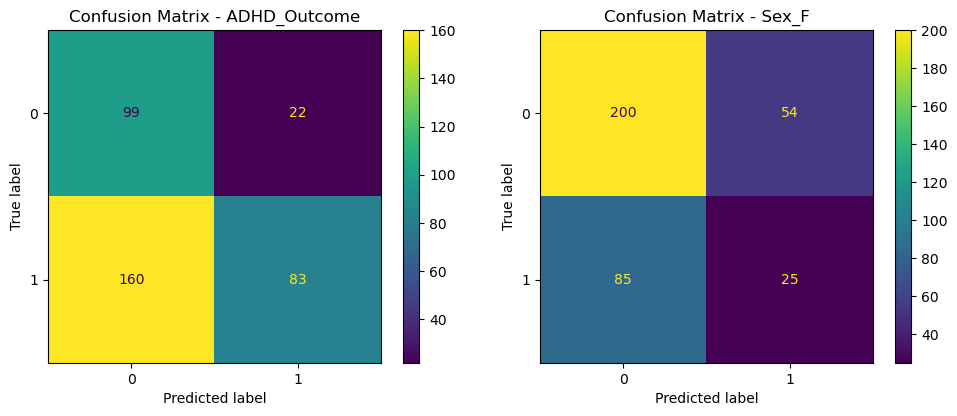

In [401]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

## Decision Trees

In [403]:
model = DecisionTreeClassifier(random_state=42)
multi_DT = MultiOutputClassifier(model)

In [404]:
param_grid = {
    'estimator__max_depth': [3, 5, 10, None],
    'estimator__min_samples_split': [2, 5],
    'estimator__min_samples_leaf': [1, 2],
    'estimator__max_features': ['sqrt', 'log2', None],
    'estimator__criterion': ['gini', 'entropy'],
    'estimator__class_weight': [None, 'balanced'],
}


### accuracy

In [406]:
grid_search = GridSearchCV(multi_DT, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)

In [407]:
# Specify the file path where the grid search results are saved
file_path = "Models/(grid_search)multi_DT_scoring=accuracy.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model exists
Model loaded


In [408]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                       max_depth=3,
                                                       random_state=42))

In [409]:
best_model.get_params()

{'estimator__ccp_alpha': 0.0,
 'estimator__class_weight': None,
 'estimator__criterion': 'entropy',
 'estimator__max_depth': 3,
 'estimator__max_features': None,
 'estimator__max_leaf_nodes': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__monotonic_cst': None,
 'estimator__random_state': 42,
 'estimator__splitter': 'best',
 'estimator': DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42),
 'n_jobs': None}

In [410]:
print("Best score:", grid_search.best_score_)

Best score: 0.49116607773851584


In [411]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.69      0.60      0.64       121
           1       0.81      0.87      0.84       243

    accuracy                           0.78       364
   macro avg       0.75      0.73      0.74       364
weighted avg       0.77      0.78      0.77       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.70      1.00      0.82       254
           1       0.67      0.02      0.04       110

    accuracy                           0.70       364
   macro avg       0.68      0.51      0.43       364
weighted avg       0.69      0.70      0.58       364



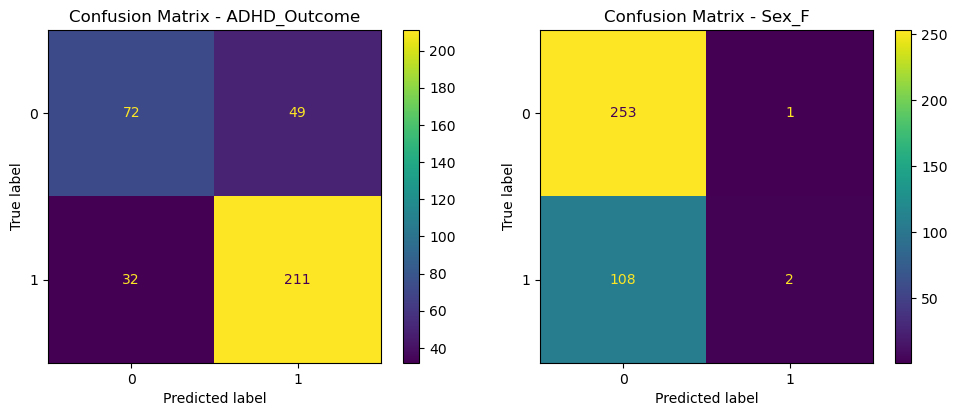

In [412]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

### multi_output_scorer

In [414]:
grid_search = GridSearchCV(multi_DT, param_grid, cv=3, scoring=multi_output_scorer, n_jobs=-1, verbose=2)

In [415]:
# Specify the file path where the grid search results are saved
file_path = "Models/(grid_search)multi_DT_scoring=multi_output_scorer.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model exists
Model loaded


In [416]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                       max_depth=3,
                                                       random_state=42))

In [417]:
best_model.get_params()

{'estimator__ccp_alpha': 0.0,
 'estimator__class_weight': None,
 'estimator__criterion': 'entropy',
 'estimator__max_depth': 3,
 'estimator__max_features': None,
 'estimator__max_leaf_nodes': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__monotonic_cst': None,
 'estimator__random_state': 42,
 'estimator__splitter': 'best',
 'estimator': DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42),
 'n_jobs': None}

In [418]:
print("Best score:", grid_search.best_score_)

Best score: 0.702002355712603


In [419]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.69      0.60      0.64       121
           1       0.81      0.87      0.84       243

    accuracy                           0.78       364
   macro avg       0.75      0.73      0.74       364
weighted avg       0.77      0.78      0.77       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.70      1.00      0.82       254
           1       0.67      0.02      0.04       110

    accuracy                           0.70       364
   macro avg       0.68      0.51      0.43       364
weighted avg       0.69      0.70      0.58       364



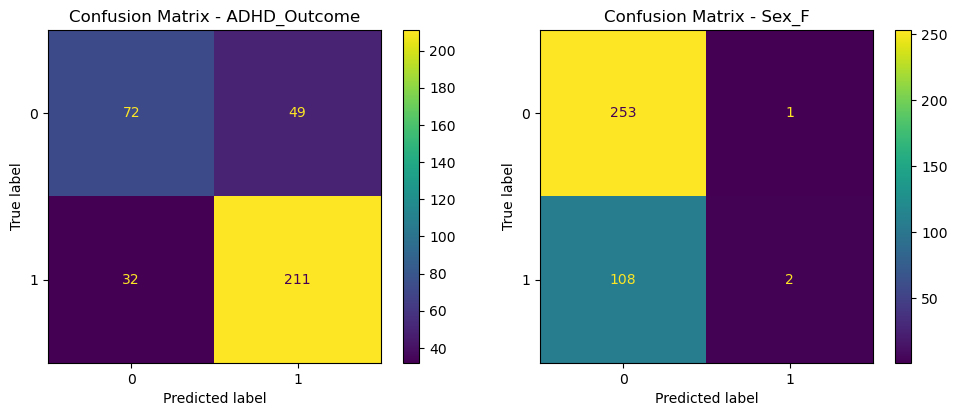

In [420]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

### f1_macro

In [422]:
grid_search = GridSearchCV(multi_DT, param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=2)

In [423]:
# Specify the file path where the grid search results are saved
file_path = "Models/(grid_search)multi_DT_scoring=f1_macro.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model exists
Model loaded


In [424]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                       max_depth=5,
                                                       random_state=42))

In [425]:
best_model.get_params()

{'estimator__ccp_alpha': 0.0,
 'estimator__class_weight': 'balanced',
 'estimator__criterion': 'gini',
 'estimator__max_depth': 5,
 'estimator__max_features': None,
 'estimator__max_leaf_nodes': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__monotonic_cst': None,
 'estimator__random_state': 42,
 'estimator__splitter': 'best',
 'estimator': DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42),
 'n_jobs': None}

In [426]:
print("Best score:", grid_search.best_score_)

Best score: 0.6564697901617343


In [427]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.55      0.64      0.59       121
           1       0.80      0.74      0.77       243

    accuracy                           0.71       364
   macro avg       0.68      0.69      0.68       364
weighted avg       0.72      0.71      0.71       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.70      0.33      0.45       254
           1       0.30      0.66      0.41       110

    accuracy                           0.43       364
   macro avg       0.50      0.50      0.43       364
weighted avg       0.58      0.43      0.44       364



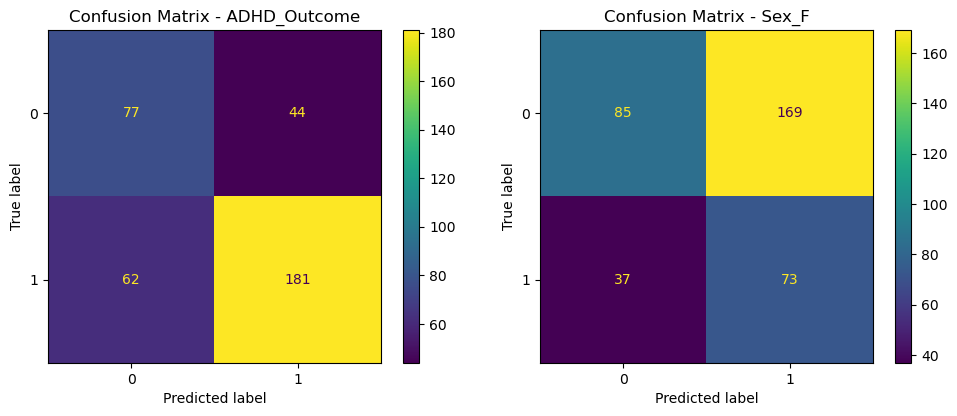

In [428]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

## Random Forests

## Logistic Regression

## Neural Networks